## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

country_drink_url = "https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv"
df = pd.read_csv(country_drink_url)
### drop the column total_litres_of_pure_alcohol 
df = df.drop(columns="total_litres_of_pure_alcohol")
### covert the data into tidy format having headers country, drink and sevings 
df_tidy = df.melt(id_vars="country", var_name="drink", value_name="servings")
df_tidy.head()

,country,drink,servings
0,Afghanistan,beer_servings,0
1,Albania,beer_servings,89
2,Algeria,beer_servings,25
3,Andorra,beer_servings,245
4,Angola,beer_servings,217


## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

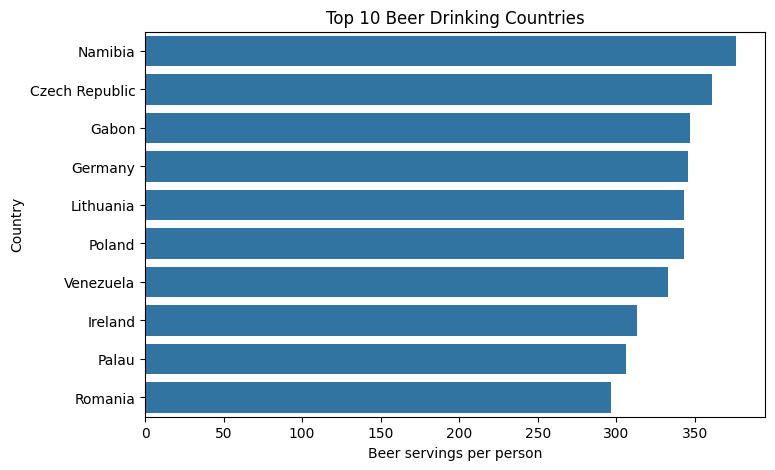

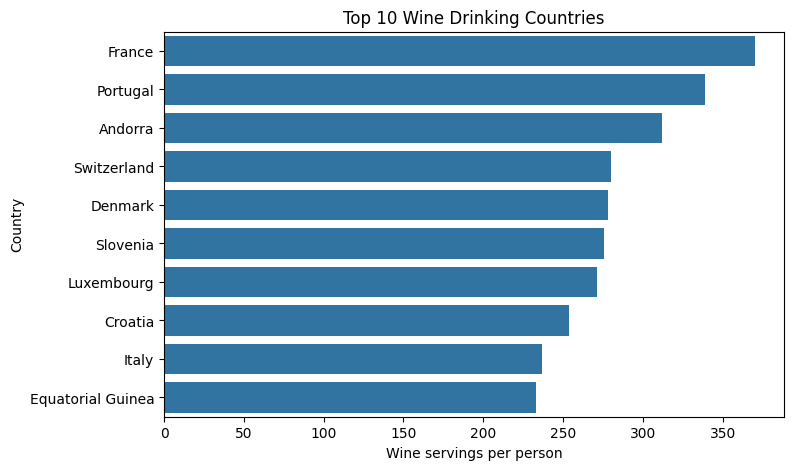

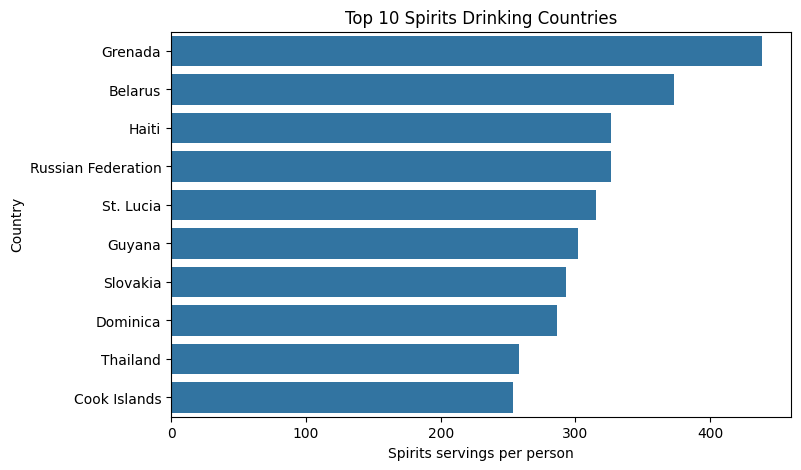

In [6]:
# Remove "_servings" from the data in the tidy dataframe in propblem 1 
df_tidy['drink'] = df_tidy['drink'].str.replace('_servings', '', regex=False)
df_tidy.head()
### Who drinks the most beer wine, and spirits?

### Create three categorical plots of your chice to illustrate the top 10 countires that drink the most wine, beer, or spirits
top_beer_countries = df_tidy[df_tidy['drink']=='beer'].sort_values(by='servings', ascending=False).head(10)
top_wine_countries = df_tidy[df_tidy['drink']=='wine'].sort_values(by='servings', ascending=False).head(10)
top_spirits_countries = df_tidy[df_tidy['drink']=='spirit'].sort_values(by='servings', ascending=False).head(10)
# beer plot
plt.figure(figsize=(8,5))
sns.barplot(data=top_beer_countries, x='servings', y='country')
plt.title("Top 10 Beer Drinking Countries")
plt.xlabel("Beer servings per person")
plt.ylabel("Country")
plt.show()

# wine plot
plt.figure(figsize=(8,5))
sns.barplot(data=top_wine_countries, x='servings', y='country')
plt.title("Top 10 Wine Drinking Countries")
plt.xlabel("Wine servings per person")
plt.ylabel("Country")
plt.show()

# spirits plot
plt.figure(figsize=(8,5))
sns.barplot(data=top_spirits_countries, x='servings', y='country')
plt.title("Top 10 Spirits Drinking Countries")
plt.xlabel("Spirits servings per person")
plt.ylabel("Country")
plt.show()

## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

In [7]:
###  Create a wide dataframe using pivot_table with the tidy dataframe from problem 2 
df_wide = df_tidy.pivot_table(
    index='country',
    columns='drink',
    values='servings'
).reset_index()

df_wide.head()

drink,country,beer,spirit,wine
0,Afghanistan,0.0,0.0,0.0
1,Albania,89.0,132.0,54.0
2,Algeria,25.0,0.0,14.0
3,Andorra,245.0,138.0,312.0
4,Angola,217.0,57.0,45.0
